In [10]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)


In [11]:
# Cell 2: Load preprocessed dataset
df = pd.read_csv("../Data/final_classification_ready.csv")

print("Shape:", df.shape)
print("Các cột:", df.columns.tolist())
df.head()


Shape: (45155, 16)
Các cột: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'HourlyDewPointTemperature', 'HourlyDryBulbTemperature', 'HourlyRelativeHumidity', 'HourlyVisibility', 'HourlyWindSpeed', 'DEP_DEL15', 'OP_UNIQUE_CARRIER_ENC', 'ORIGIN_ENC', 'DEST_ENC']


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed,DEP_DEL15,OP_UNIQUE_CARRIER_ENC,ORIGIN_ENC,DEST_ENC
0,4,1,2,6.53,9.33,168.0,1020.0,33.0,36.0,89.0,5.0,10.0,0.0,0,1,62
1,4,1,2,15.45,18.12,160.0,1020.0,33.0,45.0,63.0,10.0,10.0,1.0,0,1,62
2,4,1,2,7.33,15.32,299.0,2279.0,37.0,43.0,80.0,10.0,6.0,0.0,0,4,14
3,4,1,2,13.83,21.83,300.0,2279.0,41.0,49.0,74.0,10.0,6.0,0.0,0,4,14
4,4,1,2,22.00,6.00,300.0,2279.0,41.0,45.0,86.0,10.0,7.0,0.0,0,4,14


In [12]:
# Cell 3: Define features & target
X = df.drop(columns=["DEP_DEL15"])
y = df["DEP_DEL15"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (36124, 15) | Test: (9031, 15)


In [13]:
# Cell 4: Scale & xử lý mất cân bằng bằng SMOTE
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Áp dụng SMOTE để cân bằng lớp thiểu số (delay = 1)
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

print("Trước khi SMOTE:", np.bincount(y_train))
print("Sau khi SMOTE:", np.bincount(y_train_bal))


Trước khi SMOTE: [31882  4242]
Sau khi SMOTE: [31882 31882]


C:\Users\PC\AppData\Local\Temp\ipykernel_30664\1801914991.py:14: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Trước khi SMOTE:", np.bincount(y_train))
C:\Users\PC\AppData\Local\Temp\ipykernel_30664\1801914991.py:15: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Sau khi SMOTE:", np.bincount(y_train_bal))


In [14]:
# Cell 5: Train Logistic Regression trên dữ liệu đã SMOTE
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_bal, y_train_bal)

# Dự đoán
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]


In [15]:
# Cell 6: Evaluate metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("📊 Logistic Regression (SMOTE) Performance:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")


📊 Logistic Regression (SMOTE) Performance:
Accuracy : 0.5862
Precision: 0.1739
Recall   : 0.6736
F1-score : 0.2765
ROC-AUC  : 0.6692


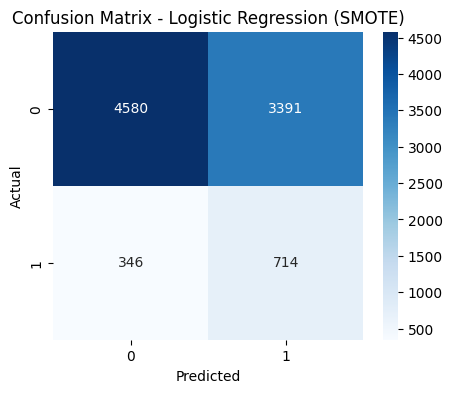

In [16]:
# Cell 7: Plot confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


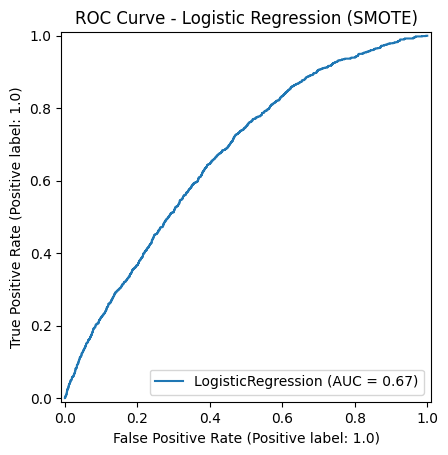

In [17]:
# Cell 8: Plot ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(log_model, X_test_scaled, y_test)
plt.title("ROC Curve - Logistic Regression (SMOTE)")
plt.show()


In [18]:
# Cell 9: Classification report
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.93      0.57      0.71      7971
         1.0       0.17      0.67      0.28      1060

    accuracy                           0.59      9031
   macro avg       0.55      0.62      0.49      9031
weighted avg       0.84      0.59      0.66      9031

